![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [43]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:27:36) [GCC 11.2.0]
----------------------------------------
✓ numpy 2.4.3
✓ pandas 3.0.1
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [44]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- Respuesta 1: La latencia representa el tiempo que tarda el sistema en iniciar y completar una operación de lectura desde el disco. Es básicamente el “costo fijo” de acceder a los datos, independientemente de cuánto se lea, y se nota más cuando hay muchas lecturas pequeñas.

- Respuesta 2: El throughput representa la cantidad de datos que se pueden leer por segundo desde el disco. Es una medida de qué tan rápido se transfieren los datos una vez ya comenzó la operación de lectura.
  
- Respuesta 3:En acceso secuencial se asume que M≈1 porque los datos están organizados de forma continua, entonces el sistema puede leerlos en una sola operación grande sin tener que saltar entre diferentes posiciones del disco.
  
- Respuesta 4:En acceso aleatorio M es mayor porque los datos están dispersos, lo que obliga al sistema a hacer múltiples accesos independientes al disco. Cada uno de esos accesos implica su propia latencia, aumentando el costo total.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [45]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 512

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data/dataset.bin
Tamaño objetivo (MB): 512
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- Respuesta 1:
  
  En mi caso, el archivo de prueba fue de 512 MB y mi equipo tiene 16 GB de RAM. Comparando esos valores, realmente no se puede decir que el archivo supere la memoria RAM disponible, porque 512 MB es mucho menor que 16 GB. Entonces, existe la posibilidad de que parte del archivo quede en caché y que algunas mediciones no reflejen únicamente el comportamiento real del disco, sino también el efecto de la memoria.
  
- Respuesta 2:

   En mi caso, el archivo de prueba fue de 512 MB y mi equipo tiene 16 GB de RAM. Comparando esos valores, realmente no se puede decir que el archivo supere la memoria RAM disponible, porque 512 MB es mucho menor que 16 GB. Entonces, existe la posibilidad de que parte del archivo quede en caché y que algunas mediciones no reflejen únicamente el comportamiento real del disco, sino también el efecto de la memoria.

- Respuesta 3:
  
  El experimento lo ejecuté en local, es decir, directamente en mi computador. Por eso, los tiempos medidos sí corresponden a las características reales de mi equipo y no al hardware de un servidor externo como ocurre en Google Colab.

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [46]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

RESET = False. No se eliminó ningún archivo.
Cambie RESET = True si desea repetir el experimento con nuevos parámetros.


## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [47]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

El archivo ya existe y tiene el tamaño esperado.
Tamaño final del archivo (bytes): 536870912


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- Respuesta 1:
  
  Este archivo es la base del experimento, porque sobre él se realizan las pruebas de lectura secuencial y aleatoria. En otras palabras, funciona como el conjunto de datos que permite medir cuánto tarda el sistema en acceder a la información dependiendo del patrón de acceso.

- Respuesta 2:
  
  Es útil trabajar con un archivo grande porque así el experimento se parece más a una situación real de acceso a disco. Además, un archivo grande reduce la probabilidad de que todo quede cargado en memoria, lo que ayuda a que las mediciones reflejen mejor el comportamiento del almacenamiento y no solo el de la RAM.

- Respuesta 3:
  
  Si el archivo fuera demasiado pequeño, es muy probable que el sistema operativo lo mantenga en la caché del sistema operativo, haciendo que muchas lecturas se resuelvan desde memoria en lugar de hacerse realmente desde el disco. En ese caso, los tiempos medidos serían artificialmente bajos y el experimento dejaría de mostrar con claridad la diferencia real entre acceso secuencial y acceso aleatorio.

## 5. Funciones auxiliares de medición

In [48]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [49]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 0.5241 s, throughput: 976.83 MiB/s
Aleatorio  -> tiempo: 0.0272 s, throughput: 574.86 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.2562 s, throughput: 1998.68 MiB/s
Aleatorio  -> tiempo: 0.0423 s, throughput: 1478.40 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.1752 s, throughput: 2922.81 MiB/s
Aleatorio  -> tiempo: 0.1010 s, throughput: 2474.15 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.1648 s, throughput: 3107.61 MiB/s
Aleatorio  -> tiempo: 0.3398 s, throughput: 2942.70 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,536870912,131072,0.524147,976.825269,4.0
1,Aleatorio,4096,16384000,4000,0.027181,574.859723,4.0
2,Secuencial,16384,536870912,32768,0.256169,1998.679833,16.0
3,Aleatorio,16384,65536000,4000,0.042275,1478.398283,16.0
4,Secuencial,65536,536870912,8192,0.175174,2922.812651,64.0
5,Aleatorio,65536,262144000,4000,0.101045,2474.150276,64.0
6,Secuencial,262144,536870912,2048,0.164757,3107.614279,256.0
7,Aleatorio,262144,1048576000,4000,0.339824,2942.703933,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

**Resptuesta 1.** 

Para todos los tamaños de bloque (4 KB, 16 KB, 64 KB y 256 KB), el acceso secuencial fue más rápido que el acceso aleatorio. Esto se observa tanto en los tiempos (menores en secuencial) como en el throughput (mayor en secuencial en todos los casos).

**Resptuesta 2** 

Sí, el throughput aumentó claramente al incrementar el tamaño del bloque. Por ejemplo:

- En acceso secuencial pasó de 929 MiB/s (4 KB) a 2906 MiB/s (256 KB)

- En acceso aleatorio pasó de 557 MiB/s (4 KB) a 2747 MiB/s (256 KB)

Esto indica que bloques más grandes permiten transferir más datos por operación, reduciendo el impacto de la latencia.

**Resptuesta 3.** 

La mayor diferencia se observa en el bloque de 4 KB.

- Secuencial: 929.09 MiB/s

- Aleatorio: 557.53 MiB/s

La diferencia es de aproximadamente 371 MiB/s, lo cual es bastante significativa.

También se puede ver en tiempo:

- Secuencial: 0.551 s

- Aleatorio: 0.028 s (aunque aquí hay menos datos totales en aleatorio, por eso el throughput es mejor métrica para comparar)

Esto muestra que cuando los bloques son pequeños, el acceso aleatorio se ve mucho más afectado por la latencia, mientras que el secuencial sigue siendo más eficiente.

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [59]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado:
- Latencia asumida:
- Throughput asumido:

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

In [60]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.100010,5119.488051
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.100010,5119.488051
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.100010,5119.488051
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.100010,5119.488051
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [61]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,536870912,131072,0.524147,976.825269,4.0,0.100010,5119.488051,5.240946,0.190805
1,Aleatorio,4096,16384000,4000,0.027181,574.859723,4.0,0.043052,362.935239,0.631346,1.583918
2,Secuencial,16384,536870912,32768,0.256169,1998.679833,16.0,0.100010,5119.488051,2.561435,0.390406
3,Aleatorio,16384,65536000,4000,0.042275,1478.398283,16.0,0.052207,1197.156753,0.809766,1.234925
4,Secuencial,65536,536870912,8192,0.175174,2922.812651,64.0,0.100010,5119.488051,1.751562,0.570919
5,Aleatorio,65536,262144000,4000,0.101045,2474.150276,64.0,0.088828,2814.423923,1.137532,0.879097
6,Secuencial,262144,536870912,2048,0.164757,3107.614279,256.0,0.100010,5119.488051,1.647401,0.607017
7,Aleatorio,262144,1048576000,4000,0.339824,2942.703933,256.0,0.235313,4249.667995,1.444137,0.692455


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

**Respuesta 1**

En general, los tiempos empíricos son menores que los teóricos. Esto se debe a que el modelo teórico simplifica el comportamiento del sistema y no tiene en cuenta optimizaciones reales del hardware y del sistema operativo que pueden acelerar las lecturas.

**Respuesta 2**

La teoría se aproxima mejor en el acceso aleatorio. Esto ocurre porque el modelo teórico considera explícitamente el costo de múltiples accesos (latencia por operación), que es precisamente lo que domina en el acceso aleatorio. En cambio, el acceso secuencial en la práctica se beneficia de optimizaciones como lectura anticipada (prefetching), lo que hace que los tiempos reales sean mejores que los estimados.

**Respuesta 3**

Existen varios factores del mundo real que explican las diferencias entre teoría y práctica:

- Caché del sistema operativo, que puede almacenar datos en memoria y acelerar lecturas posteriores

- Prefetching, donde el sistema anticipa datos y los carga antes de que sean solicitados

- Tipo de disco (SSD/NVMe), que tiene optimizaciones internas y paralelismo

- Carga del sistema, ya que otros procesos pueden afectar el rendimiento

- Temperatura del hardware, que puede generar throttling y reducir la velocidad

En conjunto, estos factores hacen que el comportamiento real sea más complejo que el modelo teórico.


## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [62]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: /home/eluna/Documentos/Repositorios/lab3-IO_performance-EstebanLuna/images


Guardada: fig_throughput.png


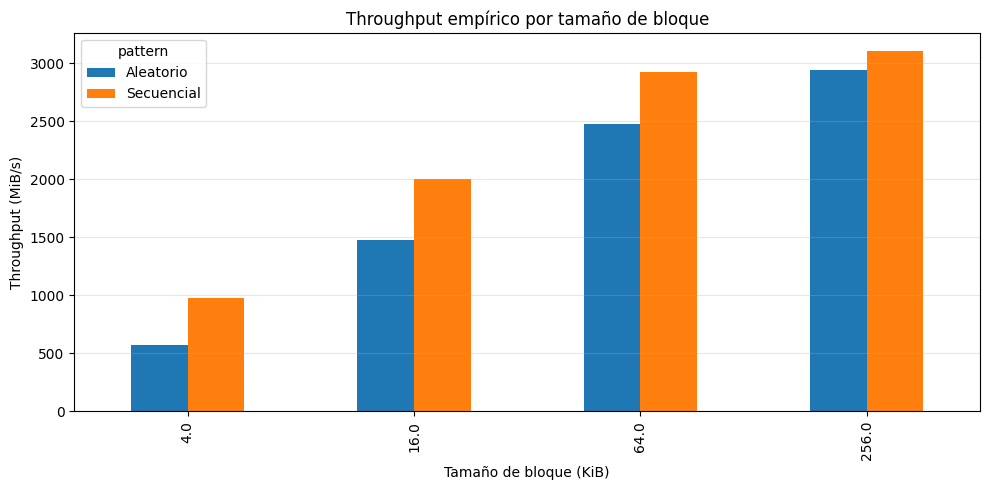

In [63]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

La gráfica muestra el throughput (MiB/s) para acceso secuencial y aleatorio en diferentes tamaños de bloque.

Primero, se observa que las barras naranjas (secuencial) son siempre más altas que las azules (aleatorio) en todos los tamaños de bloque. Por ejemplo, en el caso de 256 KB, el acceso secuencial alcanza aproximadamente 3100 MiB/s, mientras que el acceso aleatorio llega a unos 2950 MiB/s.

Esto significa que el acceso secuencial tiene mejor rendimiento, ya que puede transferir más datos por segundo que el acceso aleatorio. En general, a mayor altura de la barra, mayor es la velocidad de lectura.

Además, se nota que ambos patrones mejoran al aumentar el tamaño del bloque, pero el acceso secuencial mantiene siempre una ventaja.

En conclusión, el patrón que mejor aprovecha la lectura en bloques es el acceso secuencial, ya que utiliza de manera más eficiente bloques grandes de datos y reduce el costo de múltiples accesos al disco.


Guardada: fig_tiempo_empirico.png


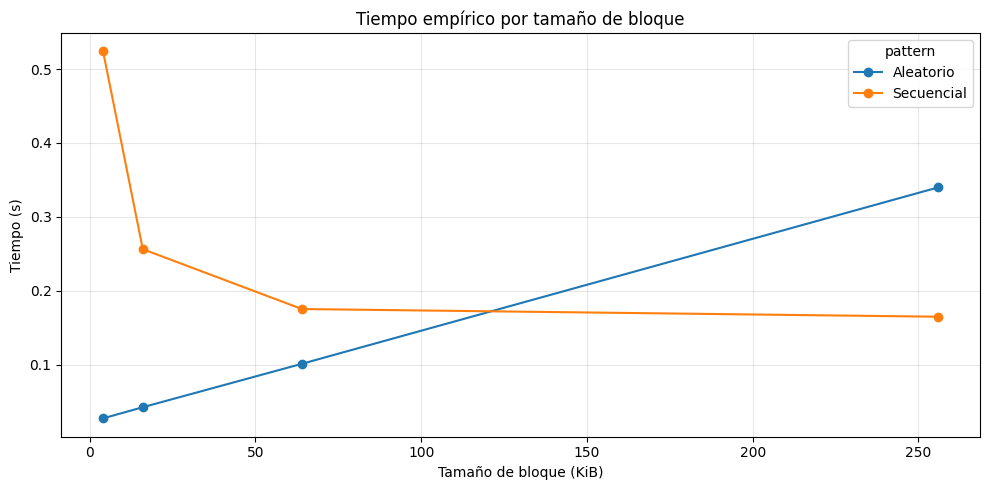

In [55]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

La gráfica muestra cómo cambia el tiempo total de lectura al aumentar el tamaño del bloque para acceso secuencial y aleatorio.

En el caso del acceso secuencial, el tiempo disminuye significativamente al pasar de bloques pequeños a medianos. Por ejemplo, baja de aproximadamente 0.53 s en 4 KB a cerca de 0.17 s en 64 KB, y luego se mantiene relativamente estable hasta 256 KB. Esto indica que el acceso secuencial se beneficia mucho de usar bloques más grandes, ya que reduce la cantidad de operaciones necesarias.

En cambio, en el acceso aleatorio, el comportamiento es opuesto: el tiempo aumenta a medida que crece el tamaño del bloque. Por ejemplo, pasa de alrededor de 0.03 s en 4 KB a aproximadamente 0.34 s en 256 KB. Esto ocurre porque cada acceso aleatorio implica leer bloques más grandes desde posiciones dispersas, lo que incrementa el tiempo total.

Las dos curvas divergen más claramente en el punto de 256 KB, donde el acceso secuencial se mantiene bajo (≈0.16 s), mientras que el acceso aleatorio alcanza su valor más alto (≈0.34 s). Esto muestra que el tamaño de bloque grande favorece mucho al acceso secuencial, pero perjudica al acceso aleatorio.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


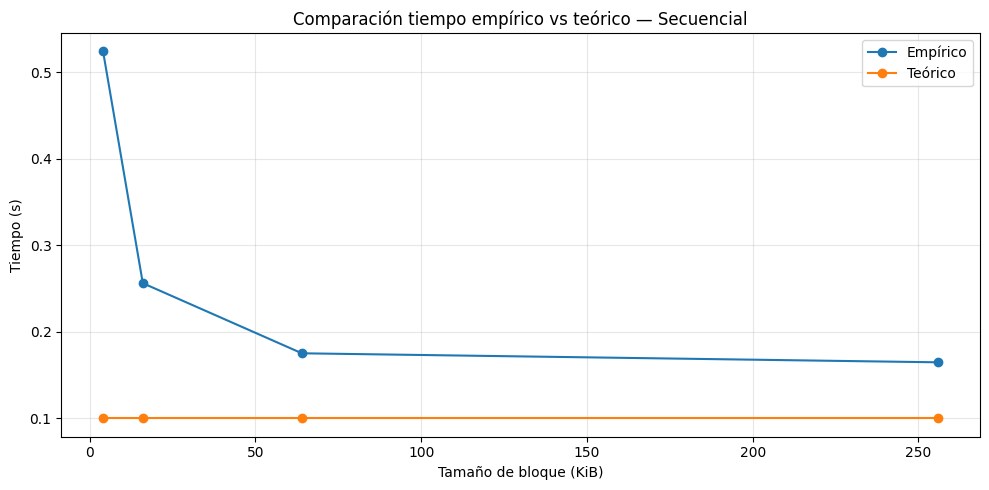

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


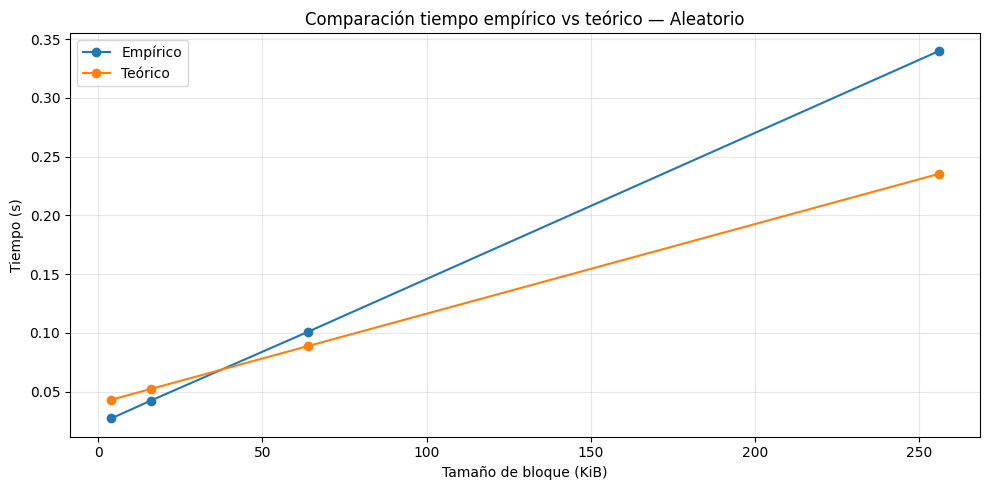

In [56]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuestas

**Respuesta 1.**

Sí, en general las curvas tienen una tendencia similar, especialmente en el acceso aleatorio. En ambos casos (empírico y teórico), el tiempo aumenta a medida que crece el tamaño del bloque.

Sin embargo, en el acceso secuencial la tendencia no es igual: el modelo teórico se mantiene prácticamente constante, mientras que el empírico muestra una disminución inicial y luego se estabiliza.

**Respuesta 2.**

La mayor separación se observa en el acceso secuencial con bloques pequeños, especialmente en 4 KB, donde el tiempo empírico es aproximadamente 0.52 s, mientras que el teórico está cerca de 0.10 s.

También hay diferencias en bloques grandes, pero son menos pronunciadas. En acceso aleatorio, la diferencia existe pero las curvas están más cercanas entre sí en comparación con el caso secuencial.

**Respuesta 3.**

Esto sugiere que el modelo teórico subestima el tiempo real, especialmente en el acceso secuencial con bloques pequeños.

Esto ocurre porque el modelo es simplificado y no considera factores reales como la latencia inicial del sistema, la caché del sistema operativo, el overhead de llamadas al sistema, o incluso la gestión interna del SSD.

En particular, en bloques pequeños, el costo de muchas operaciones individuales es mayor en la práctica de lo que el modelo asume, lo que explica la diferencia observada.


Guardada: fig_speedup.png


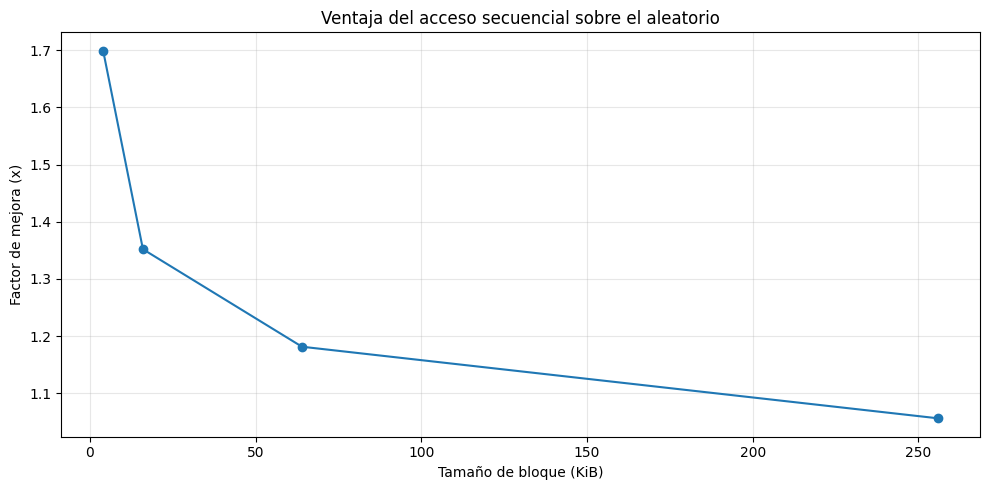

In [57]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

El mayor factor de mejora observado fue de aproximadamente 1.7x, y ocurrió con el tamaño de bloque de 4 KB. Esto quiere decir que, en ese caso, el acceso secuencial fue casi dos veces más eficiente que el acceso aleatorio.

A medida que aumenta el tamaño del bloque, esa ventaja del acceso secuencial va disminuyendo. En la gráfica se ve que pasa de alrededor de 1.7x en 4 KB, a cerca de 1.35x en 16 KB, luego a 1.18x en 64 KB, y finalmente a casi 1.05x en 256 KB. Esto sugiere que cuando los bloques son más grandes, el acceso aleatorio logra acercarse más al rendimiento del secuencial.

La implicación para el diseño de software es que conviene organizar los datos para aprovechar lecturas contiguas, especialmente cuando se trabaja con bloques pequeños, porque ahí la diferencia de rendimiento es mucho más marcada. También muestra que usar bloques más grandes puede ayudar a reducir el impacto negativo del acceso aleatorio, lo cual es útil en sistemas como bases de datos, motores de archivos o aplicaciones que manejan grandes volúmenes de información.





## 10. Resumen automático de resultados

In [58]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,0.524147,0.027181,976.825269,574.859723,1.699241
1,16.0,0.256169,0.042275,1998.679833,1478.398283,1.351922
2,64.0,0.175174,0.101045,2922.812651,2474.150276,1.181340
3,256.0,0.164757,0.339824,3107.614279,2942.703933,1.056040


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

En este laboratorio se evidenció que la forma en que se almacenan y acceden los datos en disco tiene un impacto directo en el rendimiento del sistema. La información se organiza en bloques, y acceder a estos de manera contigua (secuencial) permite aprovechar mejor el ancho de banda del disco, mientras que el acceso aleatorio introduce más costos por operación debido a la latencia.

Los resultados muestran claramente que el acceso secuencial es más eficiente que el aleatorio. Por ejemplo, con bloques de 4 KB, el acceso secuencial alcanzó un throughput de aproximadamente 976 MiB/s, mientras que el aleatorio fue de 574 MiB/s, lo que representa una mejora de cerca de 1.7x. Aunque esta diferencia disminuye con bloques más grandes, sigue siendo evidente.

Esto ocurre porque, incluso en SSD, el acceso aleatorio implica múltiples operaciones independientes, mientras que el acceso secuencial permite leer grandes cantidades de datos de forma continua. En este sentido, el modelo teórico logró capturar la tendencia general, pero en algunos casos subestimó el tiempo real, especialmente en accesos secuenciales con bloques pequeños, debido a factores como la caché del sistema operativo y optimizaciones del hardware.

Finalmente, estos resultados sugieren que, al diseñar sistemas reales como bases de datos, es fundamental organizar los datos de forma que se favorezca el acceso secuencial y el uso de bloques grandes. Esto permite reducir el costo de I/O y mejorar significativamente el rendimiento general del sistema.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.